In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


Dataset Link :- https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data

In [2]:
data = pd.read_csv("/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv")

# 1. Understanding Data

In [3]:
df = pd.DataFrame(data)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [4]:
df.shape

(50000, 16)

In [5]:
duplicates = df.duplicated().sum()
print("Total Duplicates:", duplicates)

Total Duplicates: 0


In [6]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [9]:
for col in ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']:
    print(f"\n{col}")
    print("Unique values are : ",df[col].nunique())


Tool_Diversity
Unique values are :  5

Perceived_AI_Dependency
Unique values are :  10

Anxiety_Level_During_Exams
Unique values are :  10


We can convert `Perceived_AI_Dependency` and `Anxiety_Level_During_Exams` columns into cateorical as well

In [10]:
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

for col in ['Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']:
    df[col + '_Cat'] = pd.cut(
        df[col],
        bins=[0, 2, 4, 6, 8, 10],
        labels=labels
    ).astype(str)

### Checking Spelling

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col)
    print(f"Unique Values : {df[col].unique()}")

Major_Category
Unique Values : ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
Year_of_Study
Unique Values : ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
Primary_Use_Case
Unique Values : ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
Prompt_Engineering_Skill
Unique Values : ['Beginner' 'Advanced' 'Intermediate']
Institutional_Policy
Unique Values : ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
Burnout_Risk_Level
Unique Values : ['High' 'Low' 'Medium']
Perceived_AI_Dependency_Cat
Unique Values : ['Medium' 'Low' 'Very Low' 'High' 'Very High']
Anxiety_Level_During_Exams_Cat
Unique Values : ['Medium' 'Very High' 'Very Low' 'Low' 'High']


# 2. Data Cleaning

## 2.1 Removing Irrelevant Columns

In [12]:
df = df.drop(columns= ['Student_ID','Perceived_AI_Dependency','Anxiety_Level_During_Exams'])
df.head(2)

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Institutional_Policy,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,Perceived_AI_Dependency_Cat,Anxiety_Level_During_Exams_Cat
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,Allowed_With_Citation,2.393,86.44,High,Medium,Medium
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,Allowed_With_Citation,3.696,69.39,Low,Low,Very High


## 2.2 Converting DataTypes

In [13]:
df["Paid_Subscription"] = df["Paid_Subscription"].astype(int)

# 3. EDA

In [14]:
# Columns based on Data Type 
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Numerical cols which are more good for countplot
extra_num_cols = ['Tool_Diversity', 'Paid_Subscription']

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [15]:
num_cols

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [16]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 7
Total Categorical Columns: 8


## 3.1 Univariate Analysis

### 3.1.1 Numerical columns(Histograms & Boxplots)

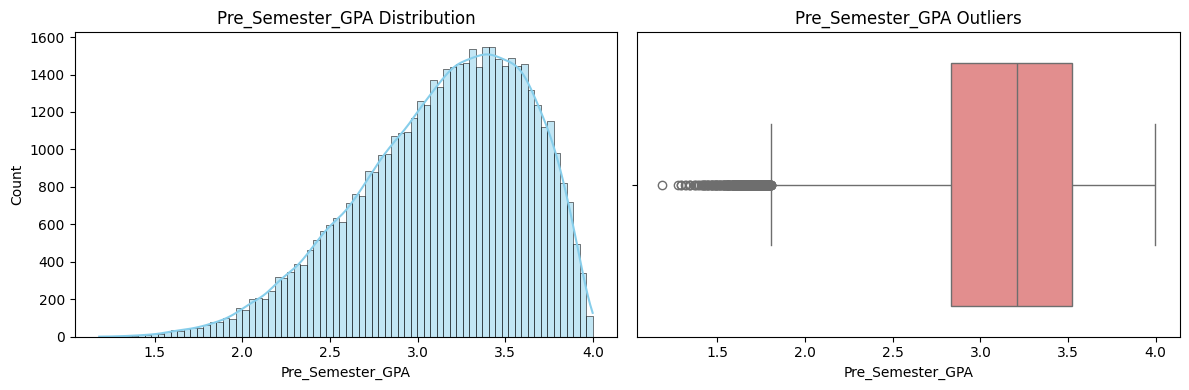

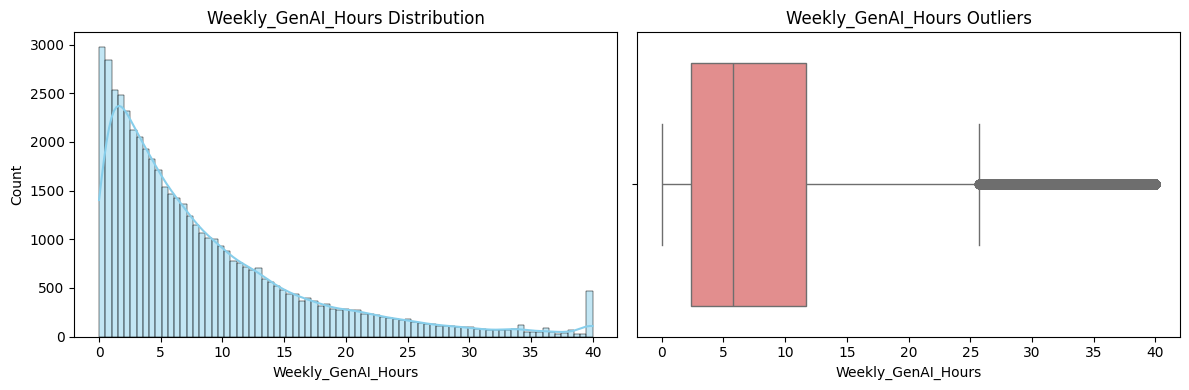

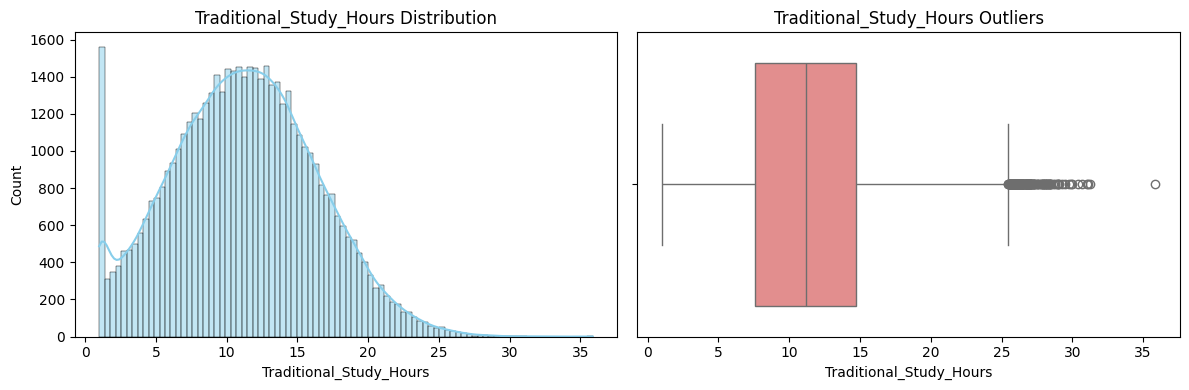

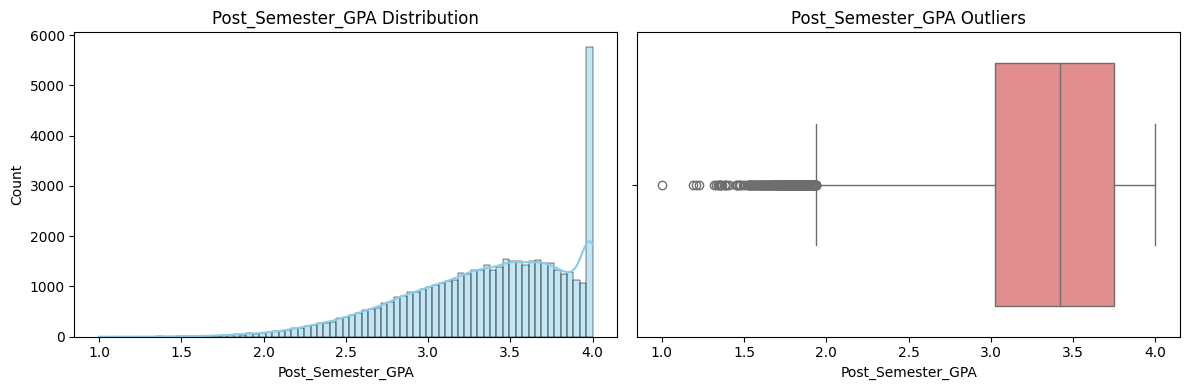

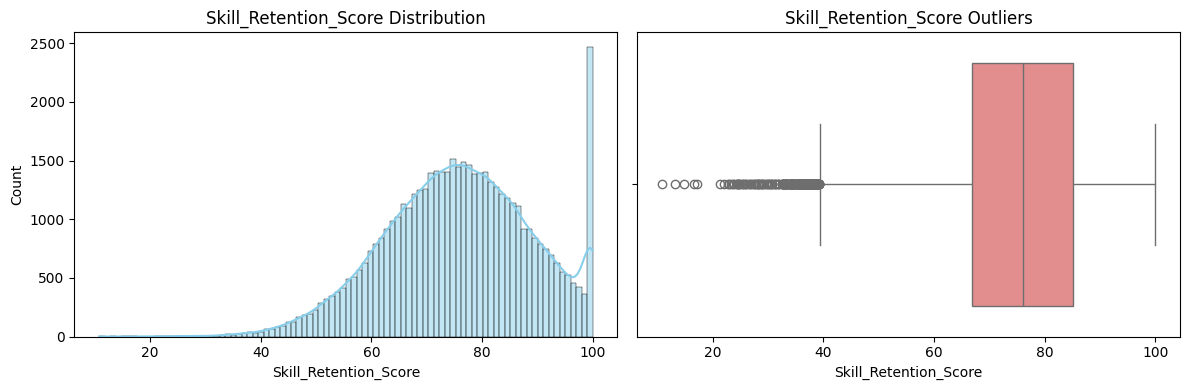

In [17]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    if col not in extra_num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Histogram with KDE curve
        sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'{col} Distribution')
        
        # Boxplot for outliers
        sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
        axes[1].set_title(f'{col} Outliers')
        
        plt.tight_layout()
        plt.show()

#### Outlier and Skewness Analysis

- **Pre_Semester_GPA:** Slightly left-skewed; no transformation required.
- **Weekly_GenAI_Hours:** Highly right-skewed; Yeo-Johnson transformation will be applied.
- **Traditional_Study_Hours:** Moderately right-skewed; Yeo-Johnson transformation will be applied.
- **Post_Semester_GPA:** Slightly left-skewed; no transformation required.
- **Skill_Retention_Score:** Approximately normal with slight left skewness; no transformation required.

**Decision:** Outliers will be retained as they appear to be valid observations. Yeo-Johnson transformation will be applied only to the skewed study-hour variables.

### 3.1.2 Categorical Columns (Count plots)

In [18]:
import math

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)   # 2 columns

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            palette='viridis',
            hue=col,
            legend=False
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

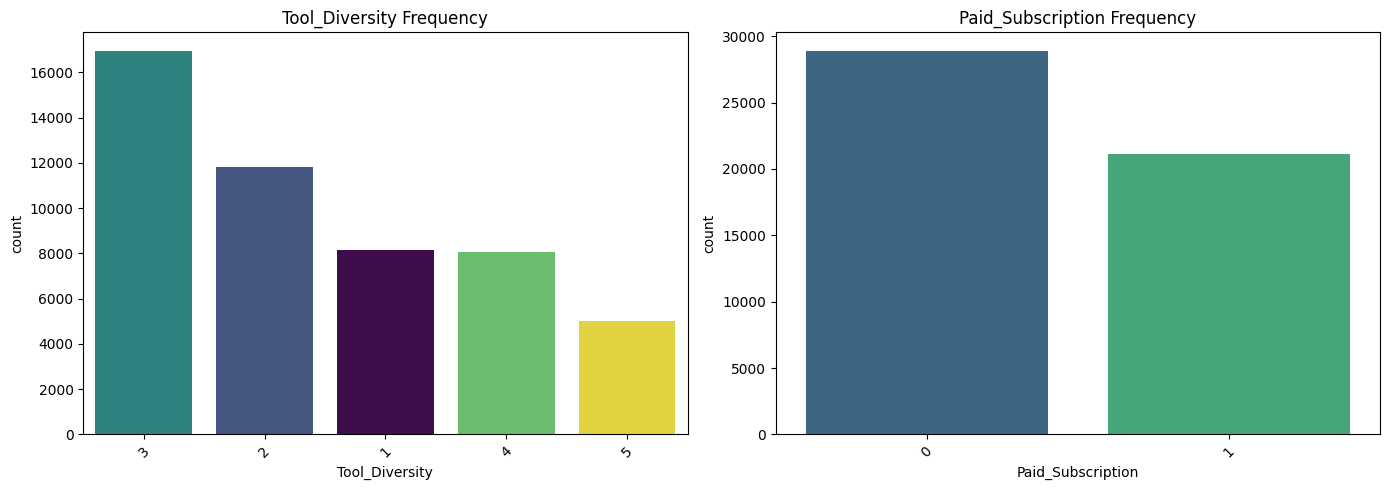

In [19]:
count_plot(extra_num_cols)

Above Plot shows that:
1. In `Tool_Diversity` majority use atleast 3 Ai Tools
2. Almost 60% of the students do not pay for any subscription 

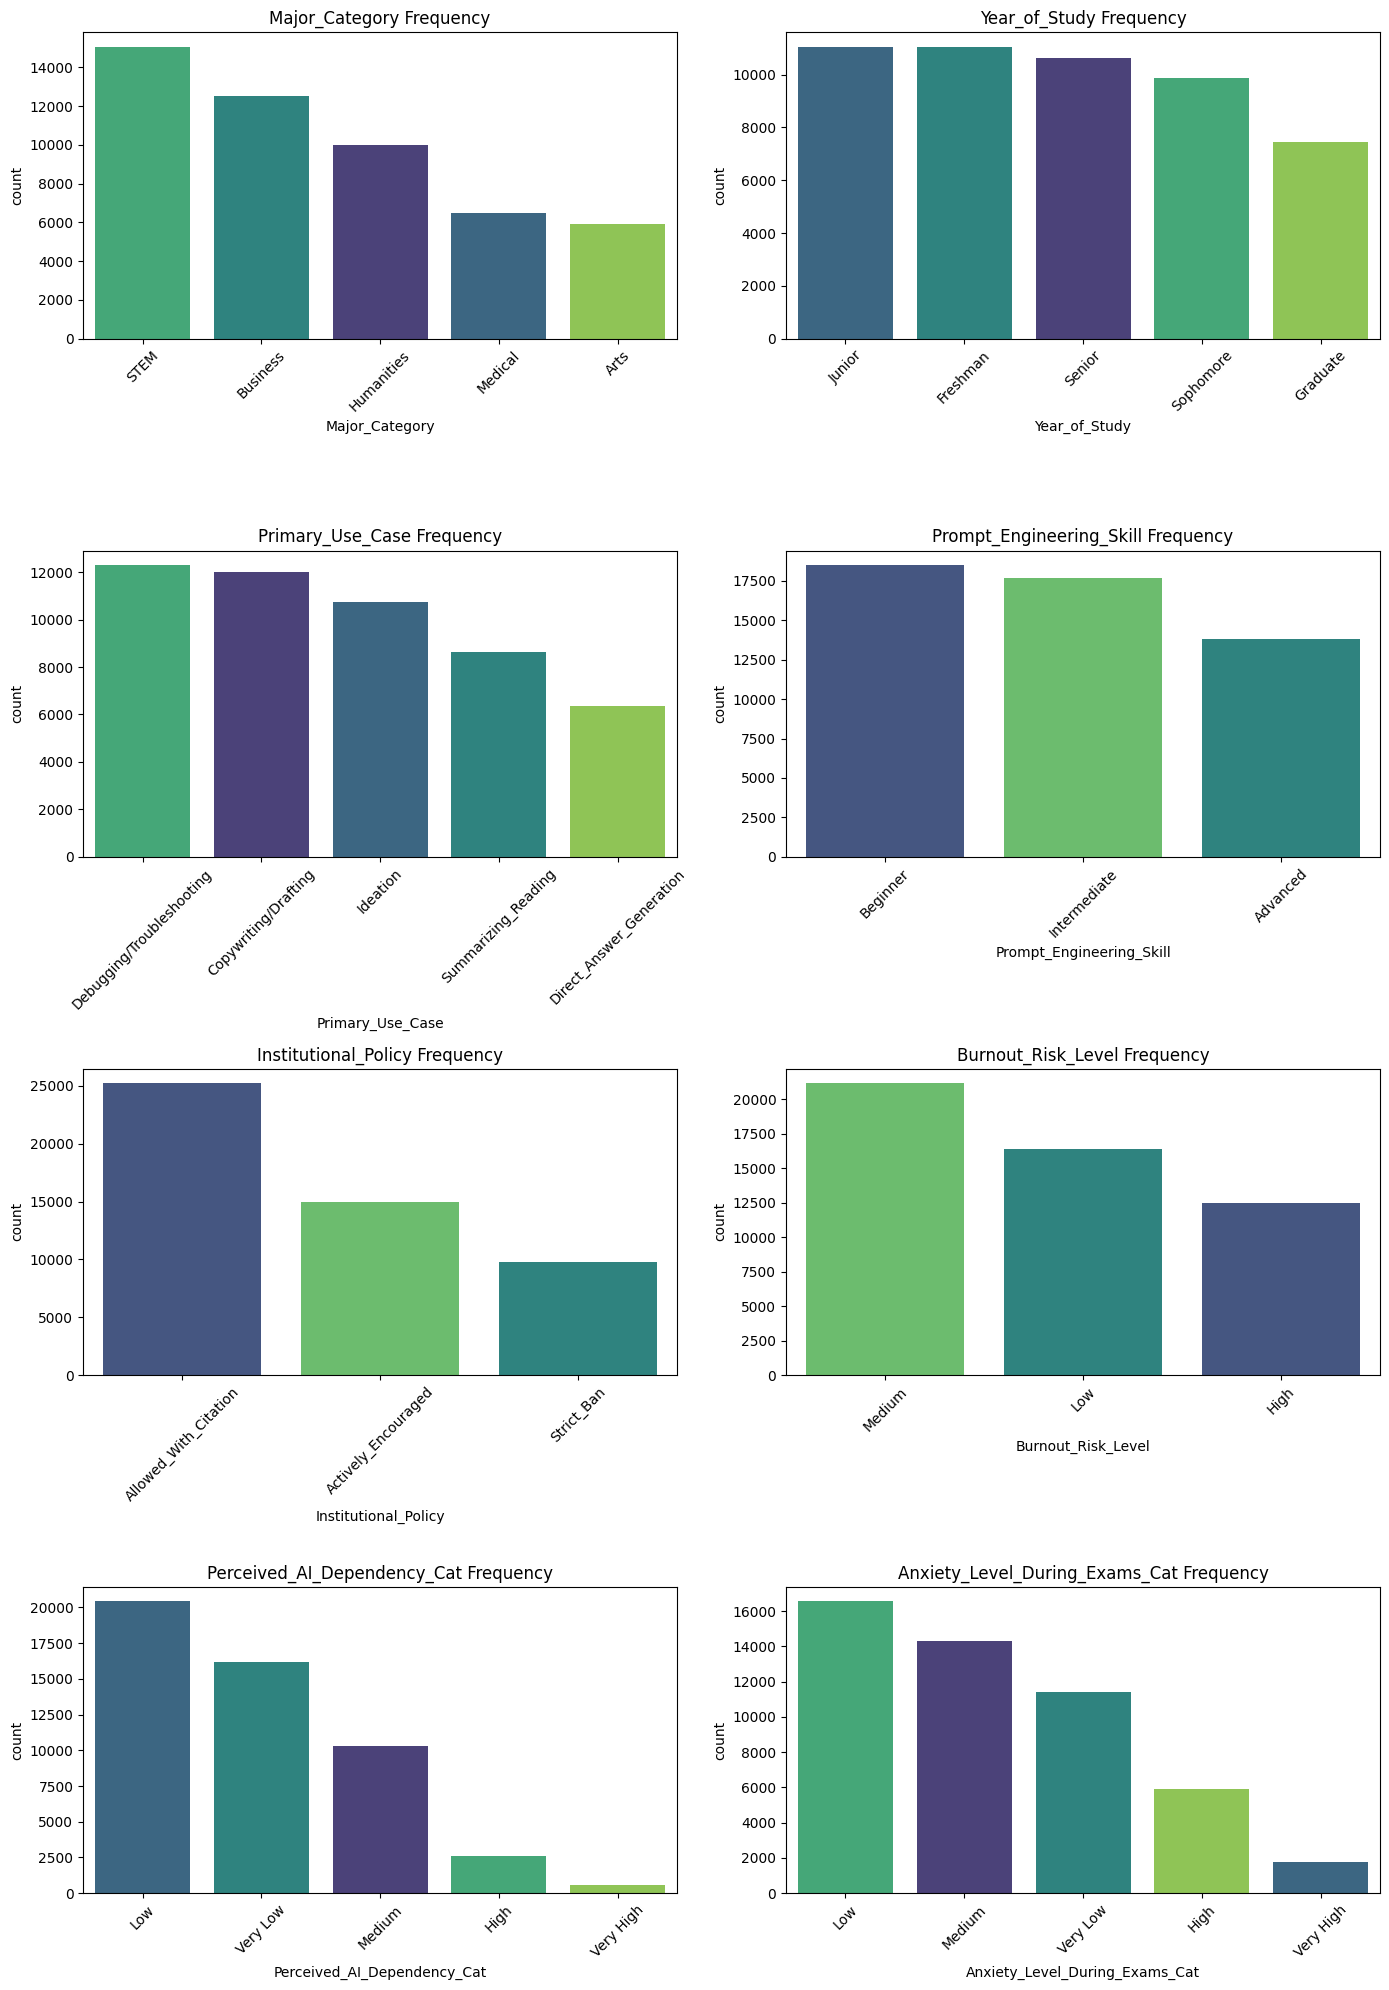

In [20]:
count_plot(cat_cols)

## 3.2 Bivariate Alanysis

### 3.2.1 Numerical vs Numerical

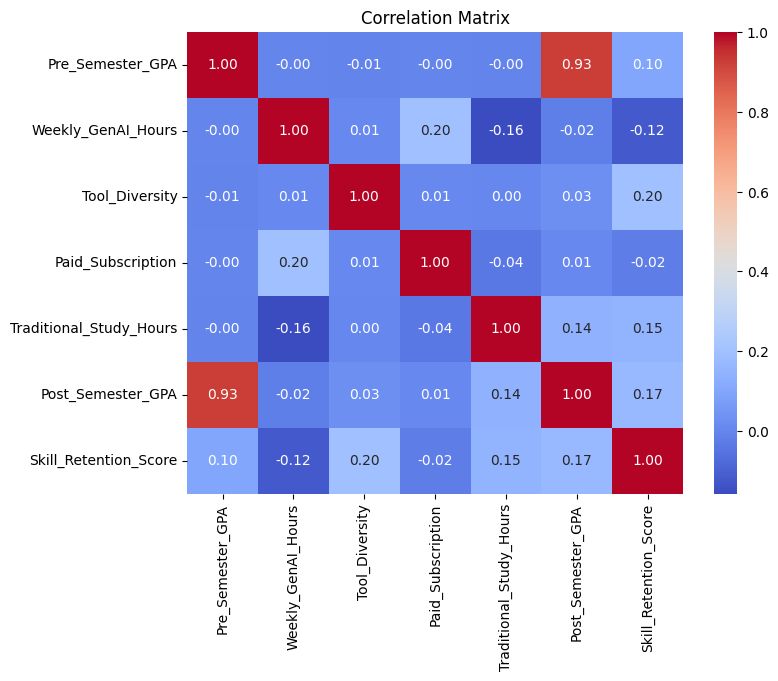

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [22]:
cat_cols

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Institutional_Policy',
 'Burnout_Risk_Level',
 'Perceived_AI_Dependency_Cat',
 'Anxiety_Level_During_Exams_Cat']

### 3.2.2. Categorical vs Categorical (Count Plot)

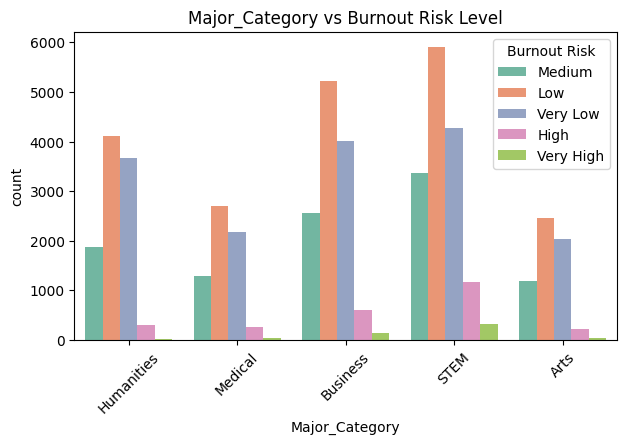

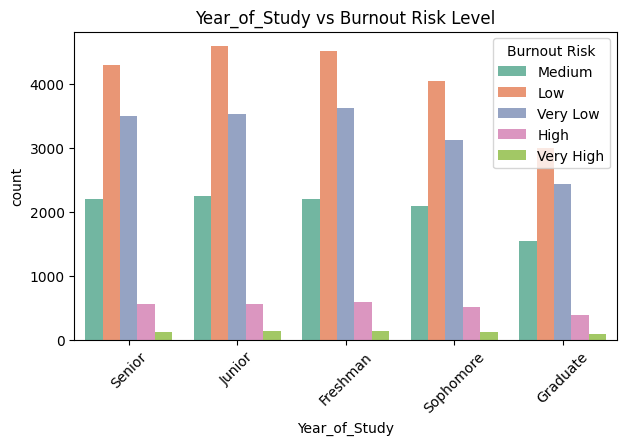

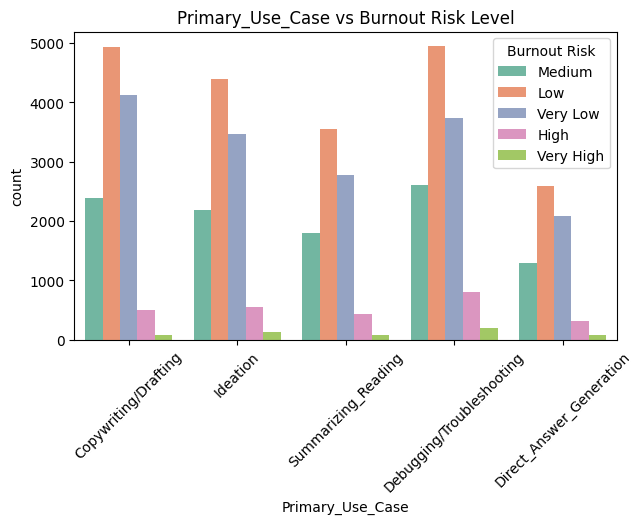

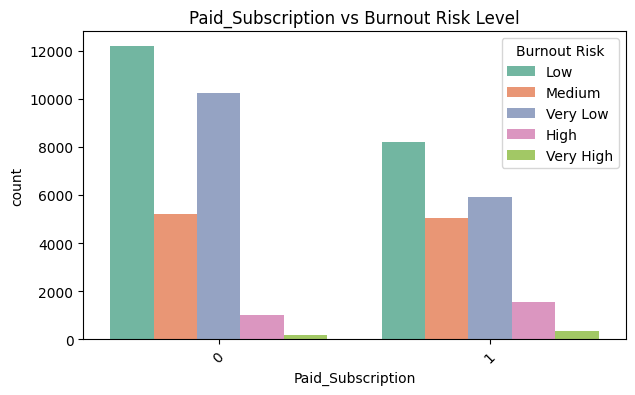

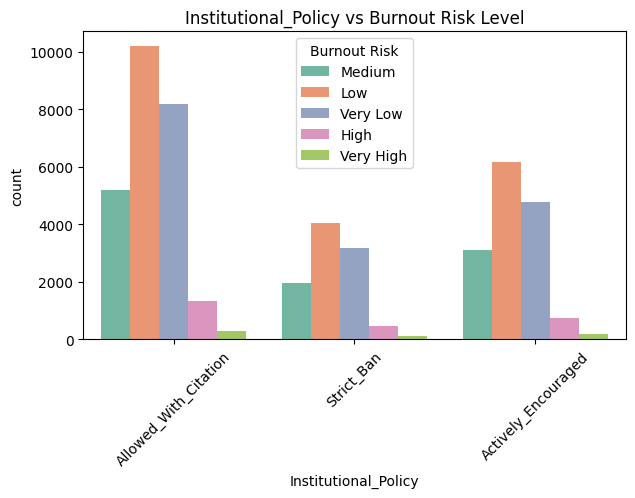

In [23]:
# Categorical features vs Burnout Risk Level

features_to_check = [
    'Major_Category',
    'Year_of_Study',
    'Primary_Use_Case',
    'Paid_Subscription',
    'Institutional_Policy'
]

for col in features_to_check:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue='Perceived_AI_Dependency_Cat', palette='Set2')
    plt.title(f'{col} vs Burnout Risk Level')
    plt.xticks(rotation=45)
    plt.legend(title='Burnout Risk')
    plt.show()

### 3.2.3 Multivariate Analysis 

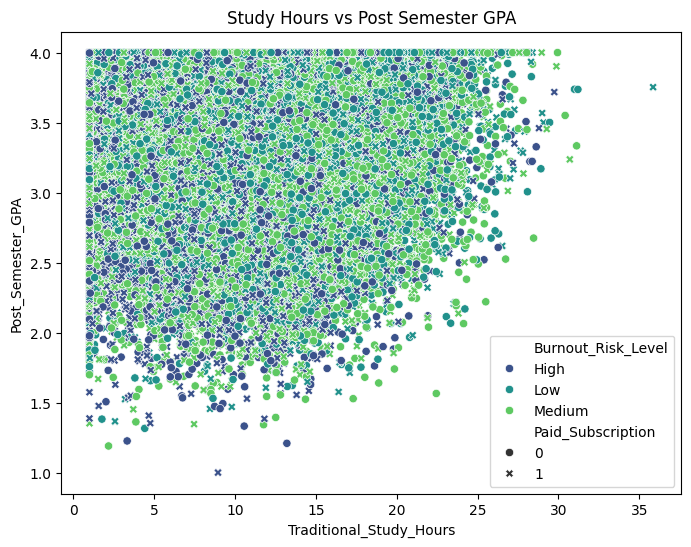

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Traditional_Study_Hours',
    y='Post_Semester_GPA',
    hue='Burnout_Risk_Level',
    style='Paid_Subscription',
    palette='viridis'
)

plt.title("Study Hours vs Post Semester GPA")
plt.show()

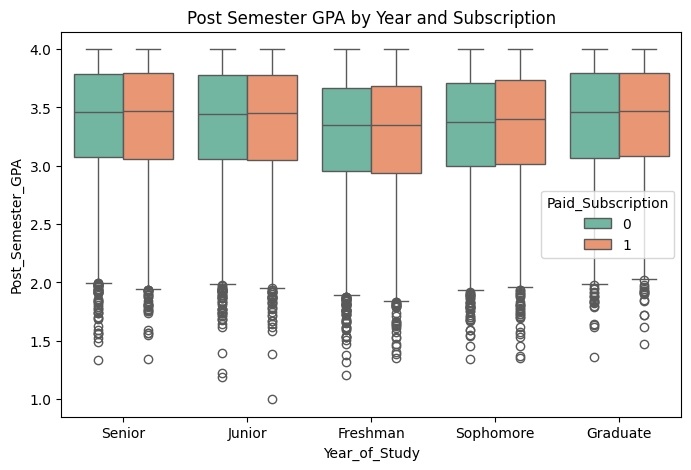

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Year_of_Study',
    y='Post_Semester_GPA',
    hue='Paid_Subscription',
    palette='Set2'
)

plt.title("Post Semester GPA by Year and Subscription")
plt.show()

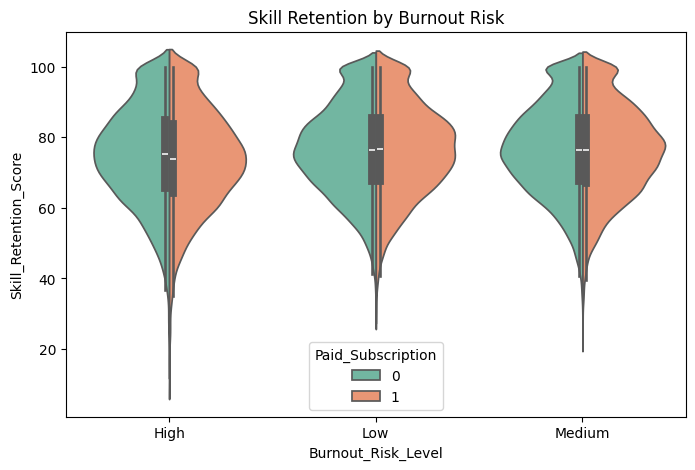

In [26]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Burnout_Risk_Level',
    y='Skill_Retention_Score',
    hue='Paid_Subscription',
    split=True,
    palette='Set2'
)

plt.title("Skill Retention by Burnout Risk")
plt.show()

# 5. Feature Transformation

In [27]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

## 5.1 Power Transformation

In [28]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

1768


In [29]:
num_cols

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [30]:
from sklearn.preprocessing import PowerTransformer

# Numerical columns to transform only
skew_cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours'
]

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')

df[skew_cols] = pt.fit_transform(df[skew_cols])

**Alternatively we can use `log1p` as well because data is right-skewed**

In [31]:
# skew_cols = [
#     'Weekly_GenAI_Hours',
#     'Traditional_Study_Hours'
# ]

# for col in skew_cols:
#     df[col] = np.log1p(df[col])   # log(1 + x) to avoid log(0)

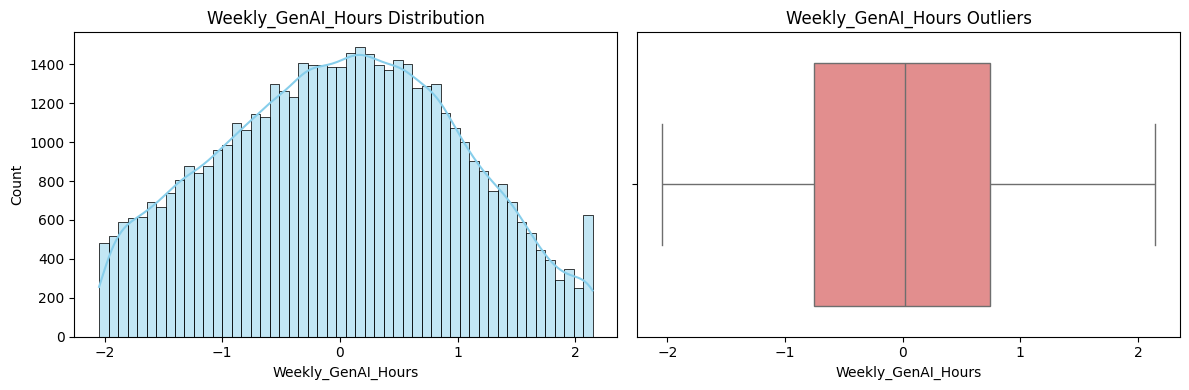

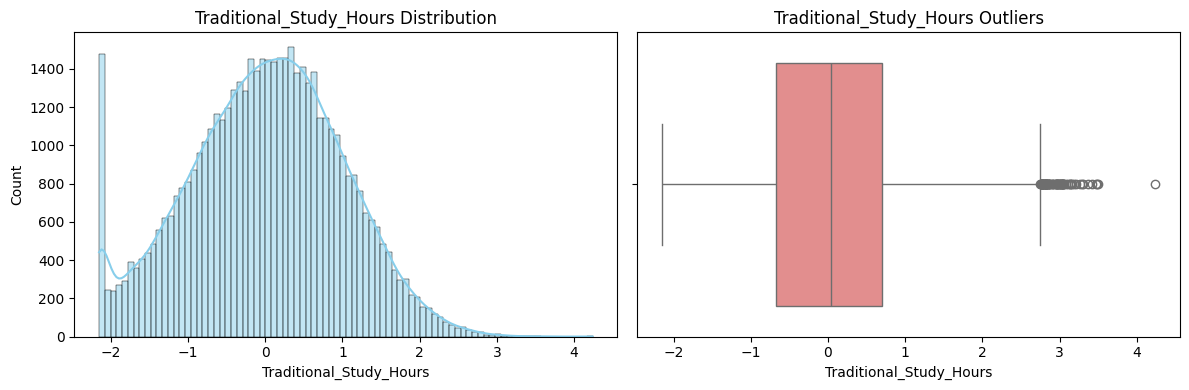

In [32]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in skew_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

As you can see applying `PowerTransformer` it remove skenwss from our dataset


In [33]:
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

578


## 5.2 One-Hot Encoding

In [34]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(data=df,columns=cat_cols,drop_first = True,dtype=int)
df.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Post_Semester_GPA,Skill_Retention_Score,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,...,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Perceived_AI_Dependency_Cat_Low,Perceived_AI_Dependency_Cat_Medium,Perceived_AI_Dependency_Cat_Very High,Perceived_AI_Dependency_Cat_Very Low,Anxiety_Level_During_Exams_Cat_Low,Anxiety_Level_During_Exams_Cat_Medium,Anxiety_Level_During_Exams_Cat_Very High,Anxiety_Level_During_Exams_Cat_Very Low
0,2.418,1.510560,1,1,-0.561736,2.393,86.44,0,1,0,...,0,0,0,1,0,0,0,1,0,0
1,3.821,-1.258326,5,0,1.044001,3.696,69.39,0,0,1,...,1,0,1,0,0,0,0,0,1,0
2,3.398,1.404749,2,0,-0.124413,3.499,73.93,1,0,0,...,0,1,0,1,0,0,0,0,1,0
3,3.789,-0.951173,4,0,0.788205,4.000,63.58,1,0,0,...,0,1,0,0,0,1,0,0,0,1
4,3.635,0.497081,4,0,0.294179,3.798,100.00,0,0,0,...,0,1,1,0,0,0,1,0,0,0


### Splitting Data before Feature scaling

In [35]:
X = df.drop('Post_Semester_GPA', axis=1)
y = df['Post_Semester_GPA']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 5.3 Standard Scaling

In [37]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [38]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Skill_Retention_Score,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,...,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Perceived_AI_Dependency_Cat_Low,Perceived_AI_Dependency_Cat_Medium,Perceived_AI_Dependency_Cat_Very High,Perceived_AI_Dependency_Cat_Very Low,Anxiety_Level_During_Exams_Cat_Low,Anxiety_Level_During_Exams_Cat_Medium,Anxiety_Level_During_Exams_Cat_Very High,Anxiety_Level_During_Exams_Cat_Very Low
39087,1.335546,0.818907,0.166223,0,-0.848820,0.433565,0,1,0,0,...,0,1,1,0,0,0,0,0,0,1
30893,1.266736,-1.248548,0.166223,0,0.083284,-2.239847,0,1,0,0,...,1,0,1,0,0,0,0,0,0,1
45278,-0.447260,-0.407924,1.006690,0,0.277477,-0.387054,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
16398,1.460655,0.071522,-0.674243,0,1.530482,-0.125811,0,0,0,1,...,1,0,1,0,0,0,0,1,0,0
13653,-2.394794,0.947872,1.847157,0,0.368928,-0.186040,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0


# 6. Machine Learning and Hyperparameter Tuning

In [39]:
from sklearn.model_selection import RandomizedSearchCV,KFold, cross_val_score

# Linear Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [40]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1  # if supported by your sklearn version
    ),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet": ElasticNet(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    # ============================
    # Boosting Models (CPU)
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',   # CPU-optimized
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1,
        n_jobs=1
    )
}

In [41]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [42]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [43]:
param_grids = {
    "Linear Regression": {},

    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10, 50, 100]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet": {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.2, 0.5, 0.8]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },


    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1],
        "colsample_bytree": [0.7, 0.8, 1]
    },

    "LightGBM": {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50],
    "max_depth": [3, 5, 7, 10],
    "min_child_samples": [10, 20]
    }
}

In [44]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():

    print(f"\nRunning GridSearchCV for {name}...")

    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    n_iter=10,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running GridSearchCV for Linear Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression
Best Params: {}
Best CV Score (R2): 0.8969143750821257

Running GridSearchCV for Ridge Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Regression
Best Params: {'alpha': 10}
Best CV Score (R2): 0.8969151697194988

Running GridSearchCV for Lasso Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso Regression
Best Params: {'alpha': 0.001}
Best CV Score (R2): 0.8958632165192342

Running GridSearchCV for ElasticNet...
ElasticNet
Best Params: {'l1_ratio': 0.2, 'alpha': 0.001}
Best CV Score (R2): 0.8968191123347975

Running GridSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10}
Best CV Score (R2): 0.8808091541711047

Running GridSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Score (R2): 0.9124259854850557

Running GridSearchCV for LightGBM...
LightGBM
Best Params: {'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.05}
Best CV Score (R2): 0.9146796513106346


In [45]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
LightGBM,"{'num_leaves': 15, 'n_estimators': 200, 'min_c...",0.91468
XGBoost,"{'subsample': 1, 'n_estimators': 500, 'max_dep...",0.912426
Ridge Regression,{'alpha': 10},0.896915
Linear Regression,{},0.896914
ElasticNet,"{'l1_ratio': 0.2, 'alpha': 0.001}",0.896819
Lasso Regression,{'alpha': 0.001},0.895863
Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.880809


In [46]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: LightGBM
Best CV Score (R2): 0.9146796513106346


In [47]:
y_pred = best_model.predict(X_test)

In [48]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.11238373365791608
RMSE: 0.14265716893263303
R2 Score: 0.9156906682107192
